# Weather Prediction Project


# 1. Library Imports & Environment Setup
Importing the core Python libraries required for data manipulation, numerical analysis, and data visualization.

Libraries: pandas, numpy, matplotlib, and seaborn.

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df =pd.read_csv("weatherAUS.csv")

| Column Name   | Description                                     |
| ------------- | ----------------------------------------------- |
| Date          | Date of weather data recording                  |
| Location      | City or location name                           |
| MinTemp       | Minimum temperature during the day (°C)         |
| MaxTemp       | Maximum temperature during the day (°C)         |
| Rainfall      | Amount of rainfall during the day (mm)          |
| Evaporation   | Amount of water evaporation during the day (mm) |
| Sunshine      | Number of sunshine hours                        |
| WindGustDir   | Direction of the strongest wind gust            |
| WindGustSpeed | Speed of the strongest wind gust (km/h)         |
| WindDir9am    | Wind direction at 9 AM                          |
| WindDir3pm    | Wind direction at 3 PM                          |
| WindSpeed9am  | Wind speed at 9 AM (km/h)                       |
| WindSpeed3pm  | Wind speed at 3 PM (km/h)                       |
| Humidity9am   | Humidity at 9 AM (%)                            |
| Humidity3pm   | Humidity at 3 PM (%)                            |
| Pressure9am   | Atmospheric pressure at 9 AM (hPa)              |
| Pressure3pm   | Atmospheric pressure at 3 PM (hPa)              |
| Cloud9am      | Cloud coverage at 9 AM (scale 0–8)              |
| Cloud3pm      | Cloud coverage at 3 PM (scale 0–8)              |
| Temp9am       | Temperature at 9 AM (°C)                        |
| Temp3pm       | Temperature at 3 PM (°C)                        |
| RainToday     | Did it rain today? (Yes / No)                   |
| RISK_MM       | Predicted rainfall amount (mm)                  |
| RainTomorrow  | Target variable: Will it rain tomorrow?         |


In [4]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


# 2. Data Loading & Initial Exploration
Loading the weatherAUS.csv dataset and conducting an initial inspection to understand its shape, columns, and data types.

Key Steps: * Displaying the first few rows using df.head().

Inspecting dataset dimensions (df.shape) and column listings (df.columns).

Reviewing data types and non-null counts using df.info().


In [5]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow'],
      dtype='object')

In [6]:
df.shape

(142193, 24)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 24 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null

# 3. Missing Value Identification
Checking the dataset for missing data to evaluate data quality and plan the cleaning strategy.

Computing total null values per column and sorting them in descending order using df.isnull().sum().

In [8]:
df.isnull().sum().sort_values(ascending=False)

Sunshine         67816
Evaporation      60843
Cloud3pm         57094
Cloud9am         53657
Pressure9am      14014
Pressure3pm      13981
WindDir9am       10013
WindGustDir       9330
WindGustSpeed     9270
WindDir3pm        3778
Humidity3pm       3610
Temp3pm           2726
WindSpeed3pm      2630
Humidity9am       1774
Rainfall          1406
RainToday         1406
WindSpeed9am      1348
Temp9am            904
MinTemp            637
MaxTemp            322
Location             0
Date                 0
RISK_MM              0
RainTomorrow         0
dtype: int64

# 4. Feature Dropping / Dimensionality Reduction
Eliminating columns with an excessively high percentage of missing values, as keeping them would introduce noise or weaken the predictive power of the model.

Dropped Columns: Evaporation, Sunshine, Cloud9am, and Cloud3pm.

In [9]:
df.drop(columns=["Evaporation","Sunshine","Cloud9am","Cloud3pm"],inplace=True)

In [10]:
df.describe()

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,40.200000,46.700000,371.000000


# 6. Numerical Data Imputation
Handling missing values within numerical columns using a robust statistical approach.

Methodology: Implementing SimpleImputer from scikit-learn with the median strategy to fill gaps without being skewed by outliers.

In [11]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
df[["Humidity3pm","Pressure9am","Pressure3pm",'Humidity9am','MaxTemp']] = imputer.fit_transform(df[["Humidity3pm","Pressure9am","Pressure3pm",'Humidity9am','MaxTemp']])

In [12]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
df[["Temp9am","Temp3pm","RISK_MM","WindSpeed3pm",'WindSpeed9am','WindGustSpeed','Rainfall','MinTemp']] = imputer.fit_transform(df[["Temp9am","Temp3pm","RISK_MM","WindSpeed3pm",'WindSpeed9am','WindGustSpeed','Rainfall','MinTemp']])

In [13]:
df.isnull().sum().sort_values(ascending=False)

WindDir9am       10013
WindGustDir       9330
WindDir3pm        3778
RainToday         1406
MaxTemp              0
MinTemp              0
Location             0
Date                 0
WindGustSpeed        0
WindSpeed9am         0
WindSpeed3pm         0
Rainfall             0
Humidity9am          0
Humidity3pm          0
Pressure3pm          0
Pressure9am          0
Temp9am              0
Temp3pm              0
RISK_MM              0
RainTomorrow         0
dtype: int64

# 7. Categorical Data Analysis & Imputation
Inspecting the text-based/categorical variables (such as wind directions and rain indicators) and resolving their missing entries.

Key Steps: * Running df.describe(include='object') to observe categorical distributions.

Applying a missing value imputer using the most_frequent (mode) strategy.

In [14]:
df.describe(include='object')

,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,142193,142193,132863,132180,138415,140787,142193
unique,3436,49,16,16,16,2,2
top,2017-06-23,Canberra,W,N,SE,No,No
freq,49,3418,9780,11393,10663,109332,110316


In [16]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="most_frequent")
df[["RainToday","WindGustDir",'WindDir9am','WindDir3pm']] = imputer.fit_transform(df[["RainToday","WindGustDir",'WindDir9am','WindDir3pm']])

# 8. Final Data Verification
Conducting a final quality check to ensure that the dataset contains zero null values across all remaining 20 features.

Key Steps: Validating with df.isnull().sum() to confirm the data is completely clean and ready for encoding and model training.

In [17]:
df.isnull().sum().sort_values(ascending=False)

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
RISK_MM          0
RainTomorrow     0
dtype: int64

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142193 entries, 0 to 142192
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        142193 non-null  float64
 3   MaxTemp        142193 non-null  float64
 4   Rainfall       142193 non-null  float64
 5   WindGustDir    142193 non-null  object 
 6   WindGustSpeed  142193 non-null  float64
 7   WindDir9am     142193 non-null  object 
 8   WindDir3pm     142193 non-null  object 
 9   WindSpeed9am   142193 non-null  float64
 10  WindSpeed3pm   142193 non-null  float64
 11  Humidity9am    142193 non-null  float64
 12  Humidity3pm    142193 non-null  float64
 13  Pressure9am    142193 non-null  float64
 14  Pressure3pm    142193 non-null  float64
 15  Temp9am        142193 non-null  float64
 16  Temp3pm        142193 non-null  float64
 17  RainToday      142193 non-nul

In [19]:
df.describe(include='object')

,Date,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,142193,142193,142193,142193,142193,142193,142193
unique,3436,49,16,16,16,2,2
top,2017-06-23,Canberra,W,N,SE,No,No
freq,49,3418,19110,21406,14441,110738,110316


In [20]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [21]:
df.drop("RISK_MM",axis=1,inplace=True)

In [22]:
df.drop('Date',axis=1,inplace=True)
df.reset_index(drop=True,inplace=True)

In [23]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,...,22.0,1007.7,1007.1,16.9,21.8,No,No,2008,12,1
1,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,...,25.0,1010.6,1007.8,17.2,24.3,No,No,2008,12,2
2,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,...,30.0,1007.6,1008.7,21.0,23.2,No,No,2008,12,3
3,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,...,16.0,1017.6,1012.8,18.1,26.5,No,No,2008,12,4
4,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,...,33.0,1010.8,1006.0,17.8,29.7,No,No,2008,12,5


# Objective

Analyze data to identify trends, patterns, and relationships.

In [24]:
x= df.pivot_table(index='Location',values='Rainfall',aggfunc='sum').sort_values(by='Rainfall',ascending=False).reset_index()

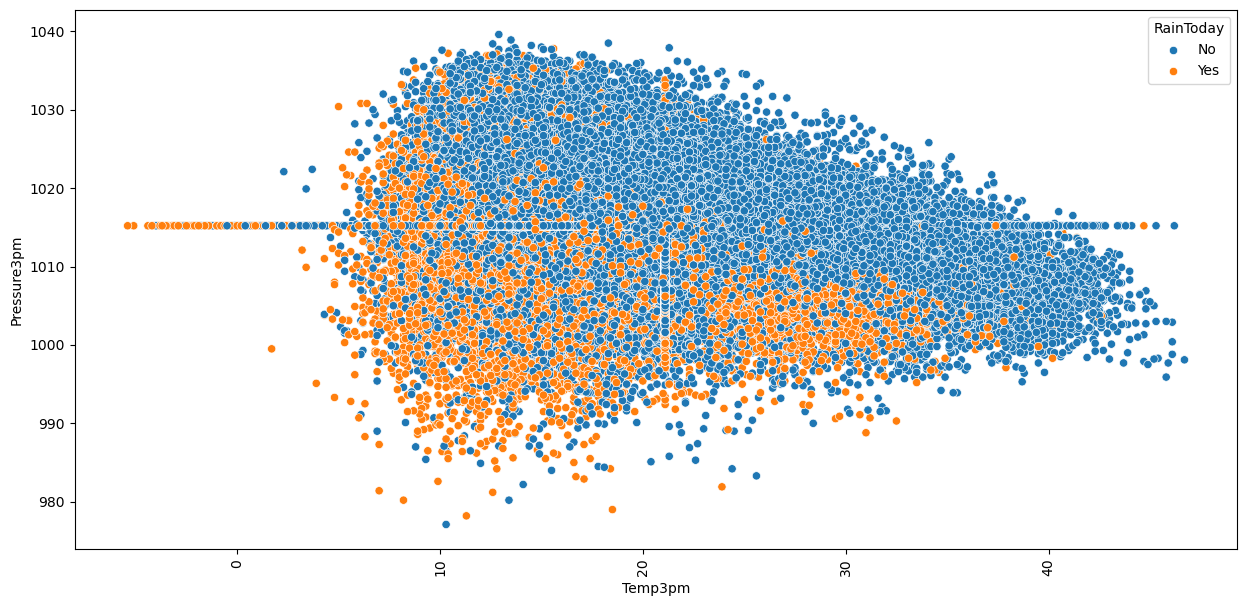

In [26]:
plt.figure(figsize=(15,7))
sns.scatterplot(x='Temp3pm',y='Pressure3pm',data=df,hue='RainToday')
plt.xticks(rotation=90)
plt.show()  

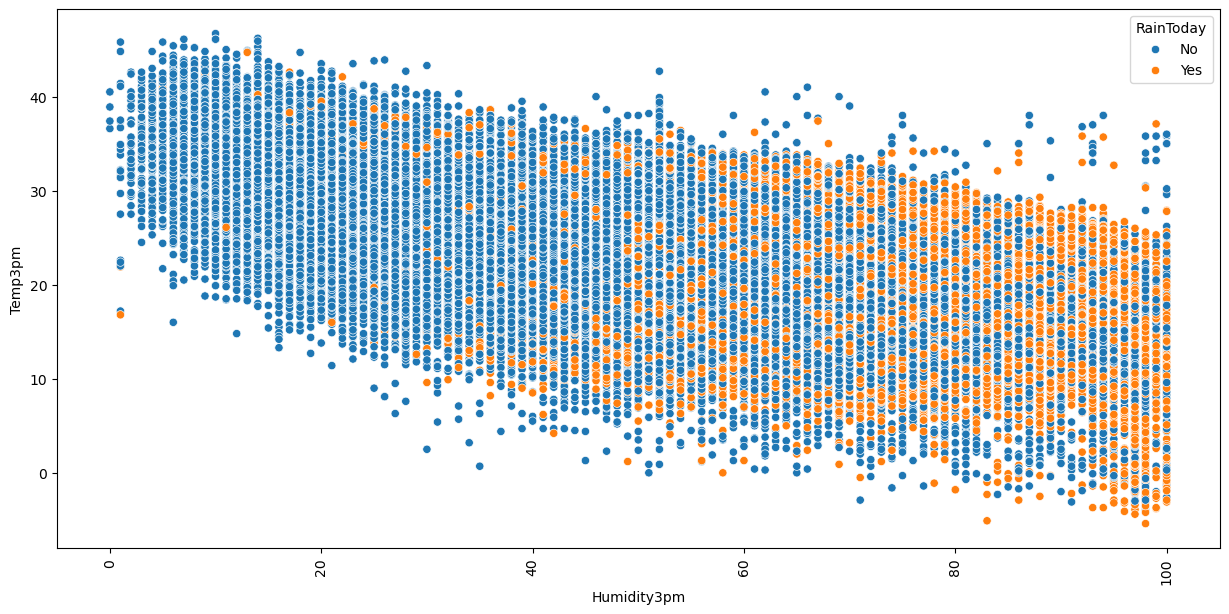

In [27]:
plt.figure(figsize=(15,7))
sns.scatterplot(x='Humidity3pm',y='Temp3pm',data=df,hue='RainToday')
plt.xticks(rotation=90)
plt.show()  

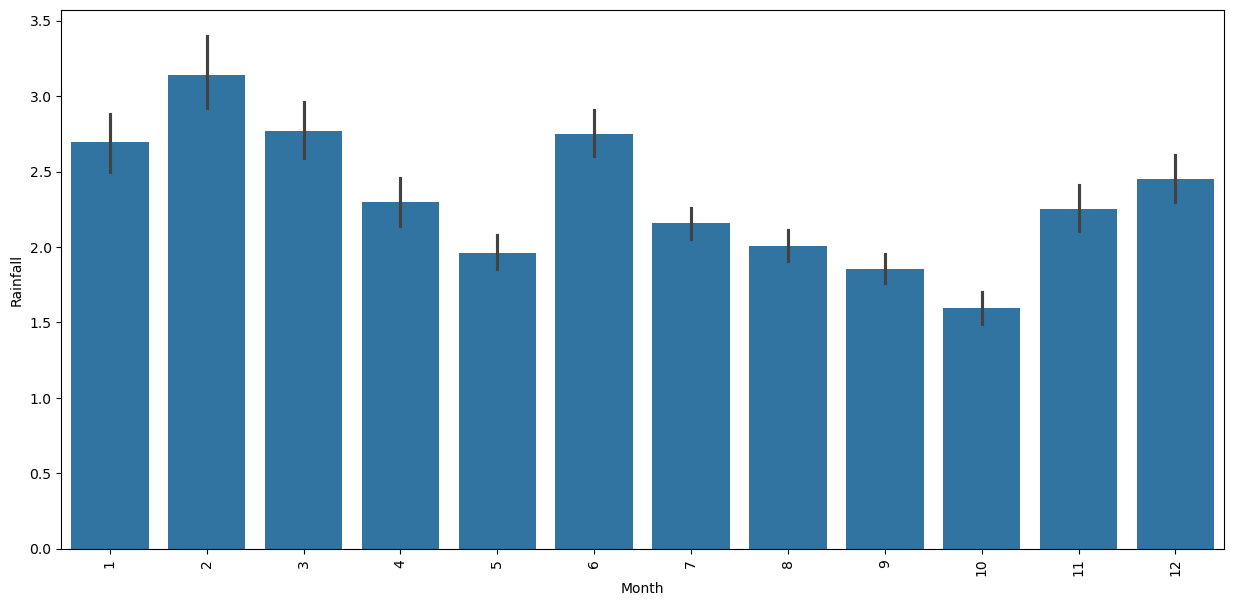

In [28]:
plt.figure(figsize=(15,7))
sns.barplot(x='Month',y='Rainfall',data=df)
plt.xticks(rotation=90)
plt.show()  

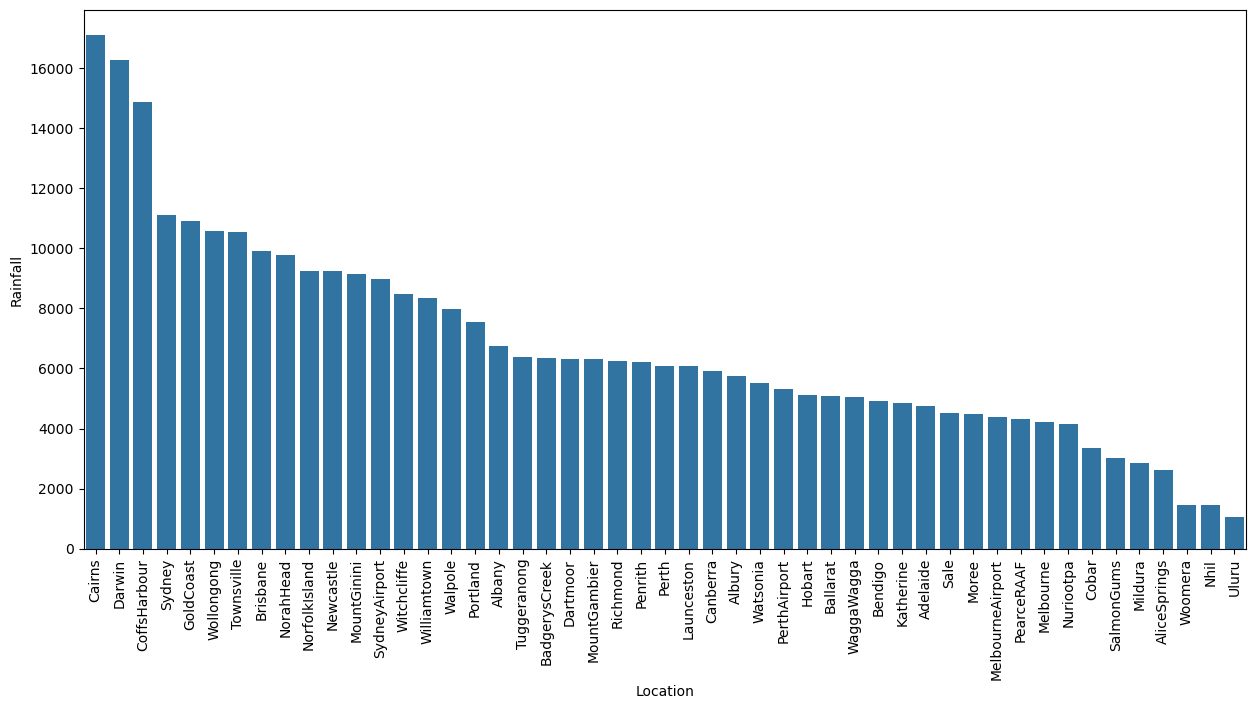

In [29]:
plt.figure(figsize=(15,7))
sns.barplot(x='Location',y='Rainfall',data=x)
plt.xticks(rotation=90)
plt.show()  

In [32]:
df.describe(include='object')

,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday,RainTomorrow
count,142193,142193,142193,142193,142193,142193
unique,49,16,16,16,2,2
top,Canberra,W,N,SE,No,No
freq,3418,19110,21406,14441,110738,110316


In [33]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['RainTomorrow'] = le.fit_transform(df['RainTomorrow'])
df['RainToday'] = le.fit_transform(df['RainToday'])

# 9. Model Training, Evaluation & Performance Metrics Comparison
Splitting the processed data into training and testing sets, training the machine learning models, and thoroughly evaluating their performance.

# Key Steps:

Calculating and comparing critical classification metrics: Accuracy, Precision, Recall, F1 Score, and Balanced Accuracy for both training and testing datasets.

Generating a comprehensive, multi-panel bar chart visualization (plt.subplot) to graphically compare these train vs. test metrics across different evaluation categories.

In [34]:
x= df.drop('RainTomorrow',axis=1)
y= df['RainTomorrow']

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,shuffle=True)

In [37]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((113754, 20), (28439, 20), (113754,), (28439,))

In [38]:
from category_encoders import TargetEncoder

cols = ['WindDir3pm','WindDir9am','WindGustDir','Location']

te = TargetEncoder()

x_train[cols] = te.fit_transform(x_train[cols], y_train)

x_test[cols] = te.transform(x_test[cols])


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,roc_curve,
    precision_recall_curve,average_precision_score
)
# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


In [40]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score 

In [41]:
models = {

    # Linear
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=1),

    # Distance-based
    "KNN": KNeighborsClassifier(n_neighbors=5),

    # SVM
    # "SVC": SVC(probability=True, random_state=1),

    # Tree
    "Decision Tree": DecisionTreeClassifier(random_state=1),

    # Naive Bayes
    "Naive Bayes": GaussianNB(),

    # Bagging Based
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1),

    # Boosting
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1),

    # External Boosting Libraries
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1),
    "LightGBM": LGBMClassifier(random_state=1)
}

  0%|          | 0/12 [00:00<?, ?it/s]e:\programdata\anconda3\envs\Ahmed\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Confusion Matrix:
 [[20808  1290]
 [ 3401  2940]]


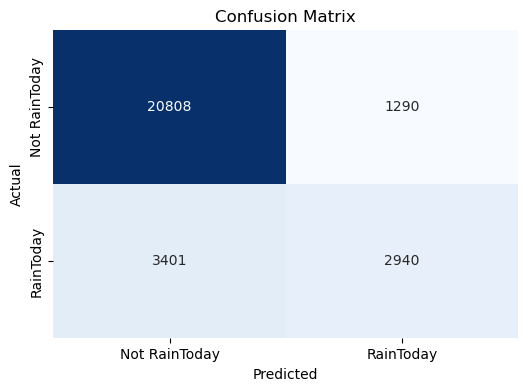


Classification Report:

               precision    recall  f1-score   support

Not RainToday       0.86      0.94      0.90     22098
    RainToday       0.70      0.46      0.56      6341

     accuracy                           0.84     28439
    macro avg       0.78      0.70      0.73     28439
 weighted avg       0.82      0.84      0.82     28439

ROC-AUC: 0.8462380570819361


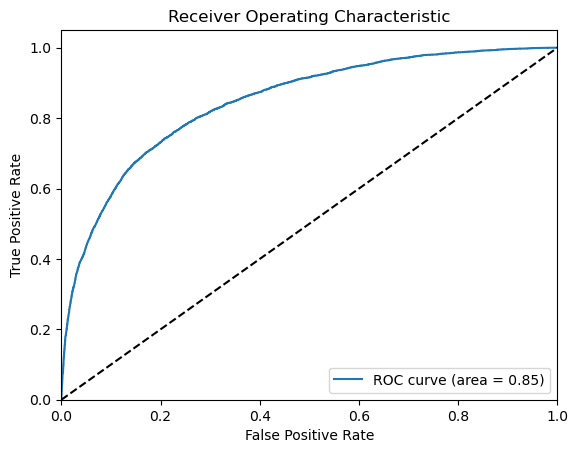

PR AUC: 0.651689445935653


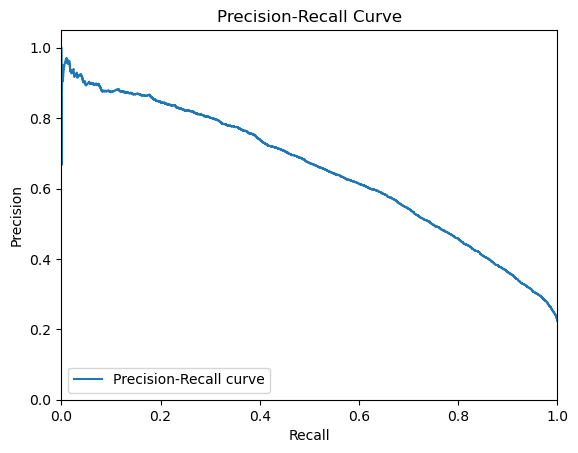

  8%|▊         | 1/12 [00:12<02:15, 12.29s/it]


Confusion Matrix:
 [[20500  1598]
 [ 3196  3145]]


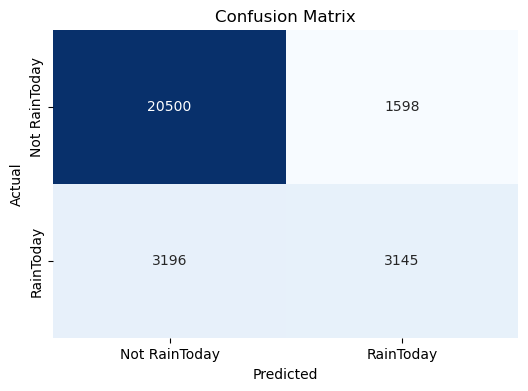


Classification Report:

               precision    recall  f1-score   support

Not RainToday       0.87      0.93      0.90     22098
    RainToday       0.66      0.50      0.57      6341

     accuracy                           0.83     28439
    macro avg       0.76      0.71      0.73     28439
 weighted avg       0.82      0.83      0.82     28439

ROC-AUC: 0.8026461822391457


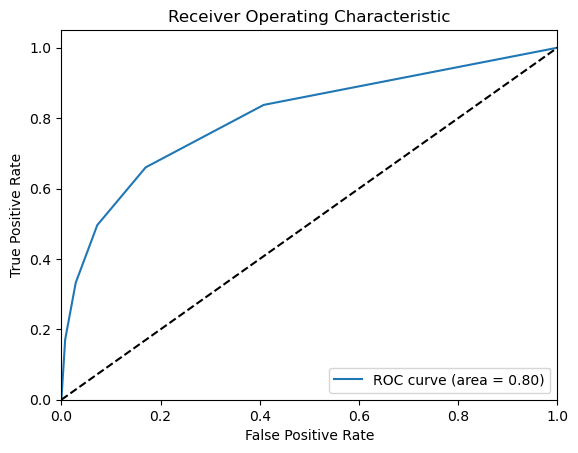

PR AUC: 0.5689638828954552


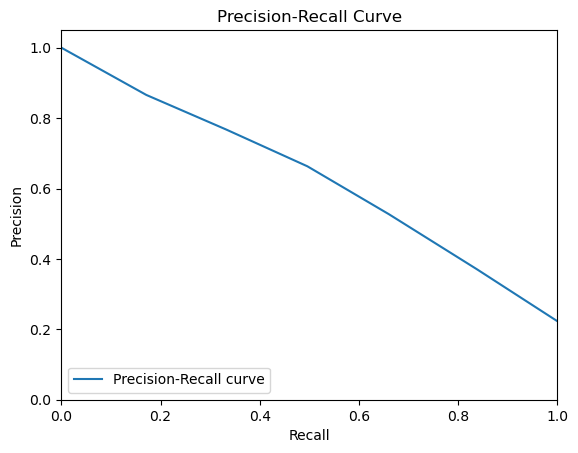

 17%|█▋        | 2/12 [00:29<02:31, 15.19s/it]


Confusion Matrix:
 [[18812  3286]
 [ 2897  3444]]


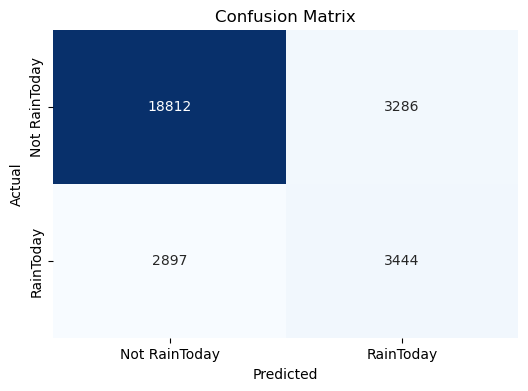


Classification Report:

               precision    recall  f1-score   support

Not RainToday       0.87      0.85      0.86     22098
    RainToday       0.51      0.54      0.53      6341

     accuracy                           0.78     28439
    macro avg       0.69      0.70      0.69     28439
 weighted avg       0.79      0.78      0.78     28439

ROC-AUC: 0.6972153790881692


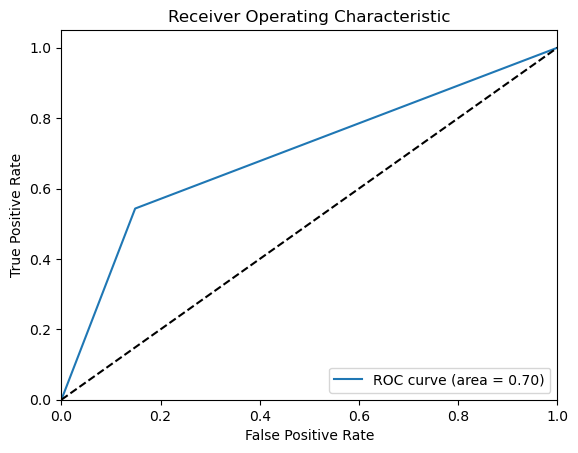

PR AUC: 0.37980869979973


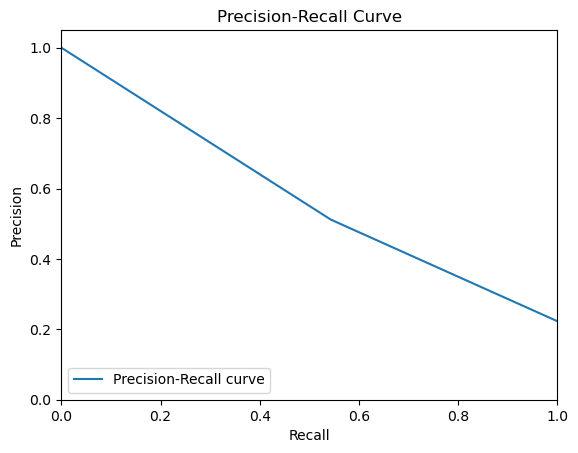

 25%|██▌       | 3/12 [00:32<01:25,  9.53s/it]


Confusion Matrix:
 [[19493  2605]
 [ 2991  3350]]


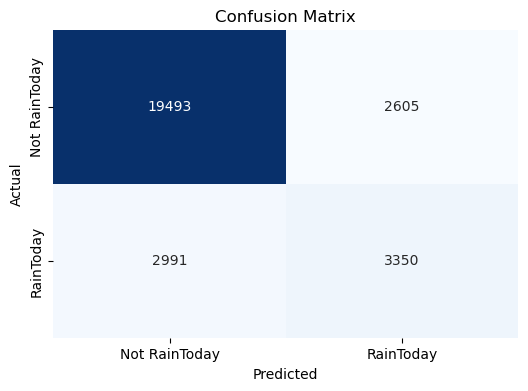


Classification Report:

               precision    recall  f1-score   support

Not RainToday       0.87      0.88      0.87     22098
    RainToday       0.56      0.53      0.54      6341

     accuracy                           0.80     28439
    macro avg       0.71      0.71      0.71     28439
 weighted avg       0.80      0.80      0.80     28439

ROC-AUC: 0.8084408346362204


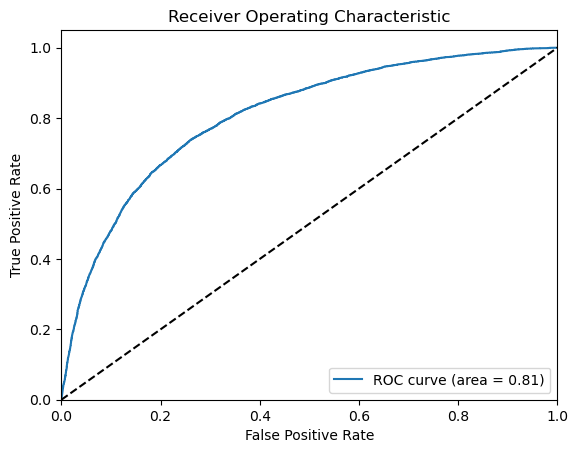

PR AUC: 0.5503703324781031


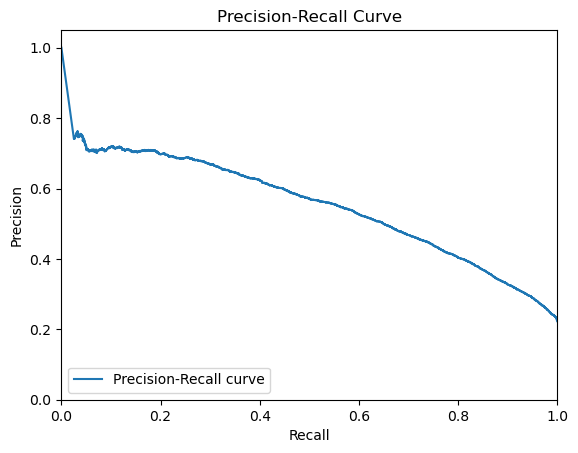

 33%|███▎      | 4/12 [00:33<00:48,  6.04s/it]


Confusion Matrix:
 [[21110   988]
 [ 3165  3176]]


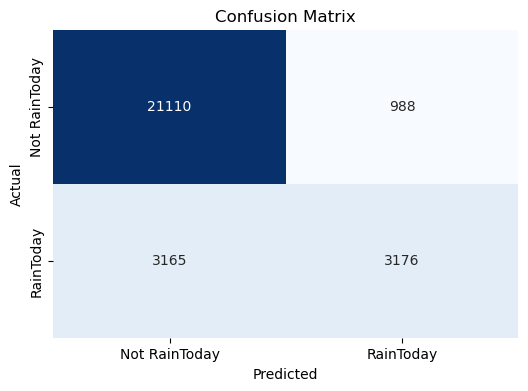


Classification Report:

               precision    recall  f1-score   support

Not RainToday       0.87      0.96      0.91     22098
    RainToday       0.76      0.50      0.60      6341

     accuracy                           0.85     28439
    macro avg       0.82      0.73      0.76     28439
 weighted avg       0.85      0.85      0.84     28439

ROC-AUC: 0.8770812920078784


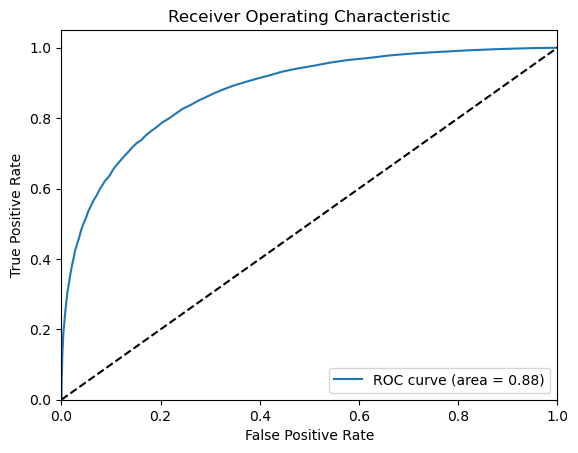

PR AUC: 0.7157670738815178


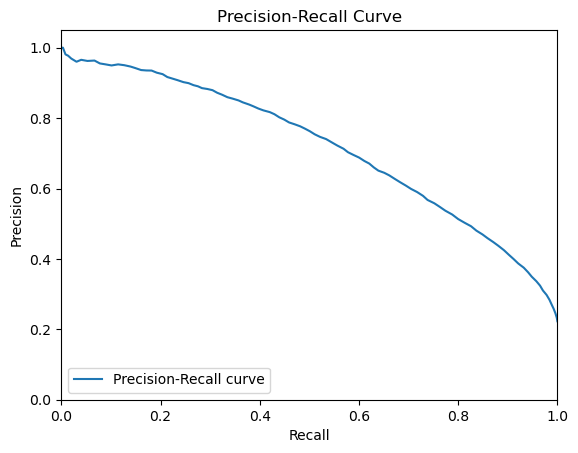

 42%|████▏     | 5/12 [01:13<02:09, 18.43s/it]


Confusion Matrix:
 [[21161   937]
 [ 3244  3097]]


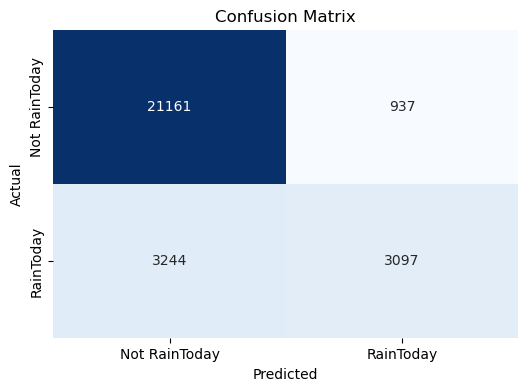


Classification Report:

               precision    recall  f1-score   support

Not RainToday       0.87      0.96      0.91     22098
    RainToday       0.77      0.49      0.60      6341

     accuracy                           0.85     28439
    macro avg       0.82      0.72      0.75     28439
 weighted avg       0.84      0.85      0.84     28439

ROC-AUC: 0.8785142252239379


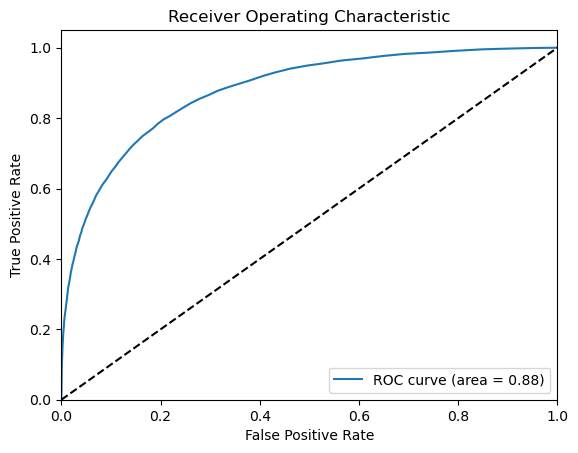

PR AUC: 0.7179229749807681


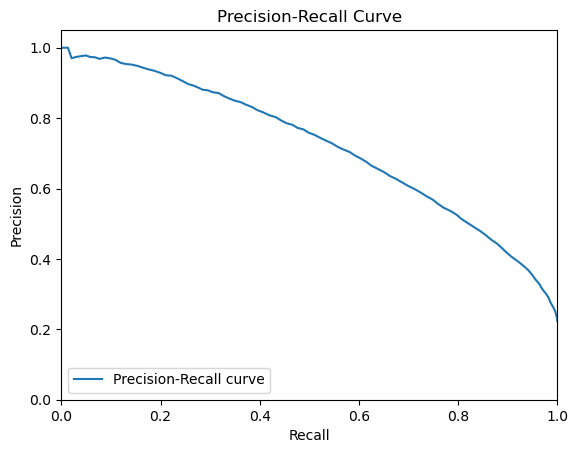

 50%|█████     | 6/12 [01:40<02:08, 21.49s/it]


Confusion Matrix:
 [[20723  1375]
 [ 3363  2978]]


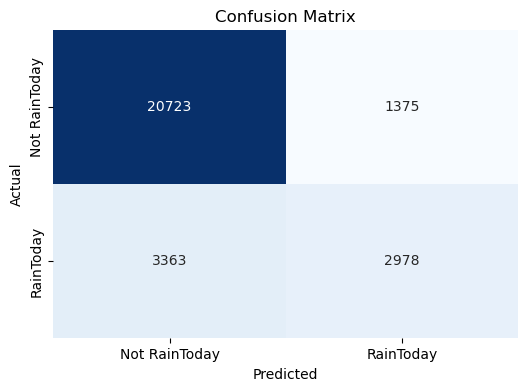


Classification Report:

               precision    recall  f1-score   support

Not RainToday       0.86      0.94      0.90     22098
    RainToday       0.68      0.47      0.56      6341

     accuracy                           0.83     28439
    macro avg       0.77      0.70      0.73     28439
 weighted avg       0.82      0.83      0.82     28439

ROC-AUC: 0.8372790049982937


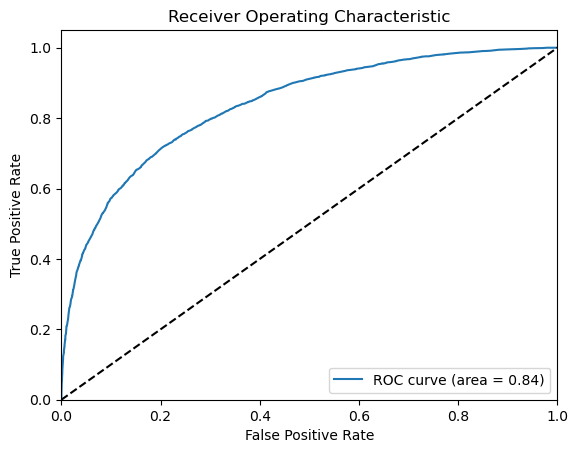

PR AUC: 0.6474324547304648


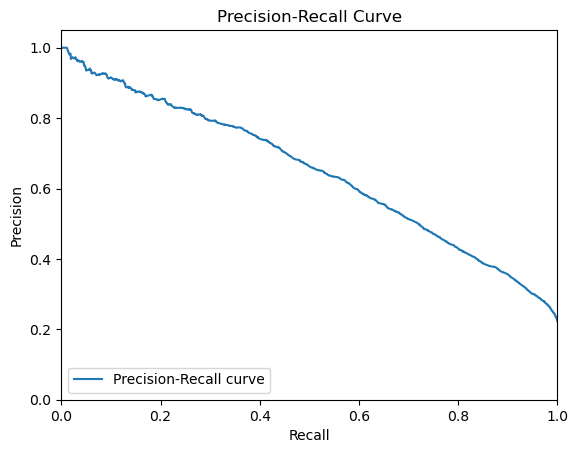

 58%|█████▊    | 7/12 [01:49<01:26, 17.28s/it]


Confusion Matrix:
 [[20993  1105]
 [ 3262  3079]]


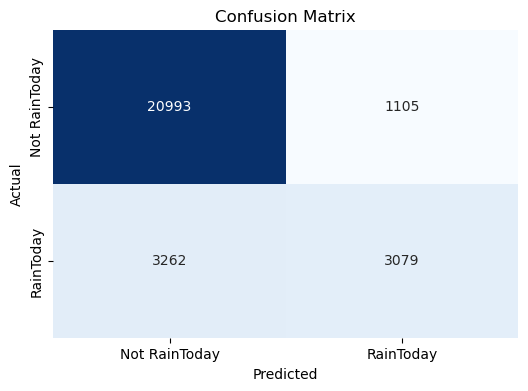


Classification Report:

               precision    recall  f1-score   support

Not RainToday       0.87      0.95      0.91     22098
    RainToday       0.74      0.49      0.59      6341

     accuracy                           0.85     28439
    macro avg       0.80      0.72      0.75     28439
 weighted avg       0.84      0.85      0.83     28439

ROC-AUC: 0.8583320954959862


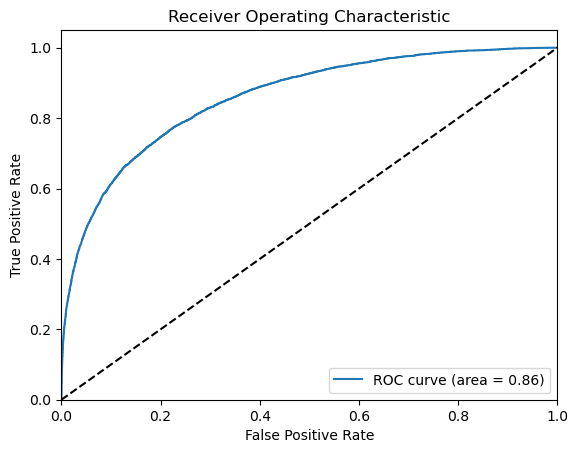

PR AUC: 0.6911479147581813


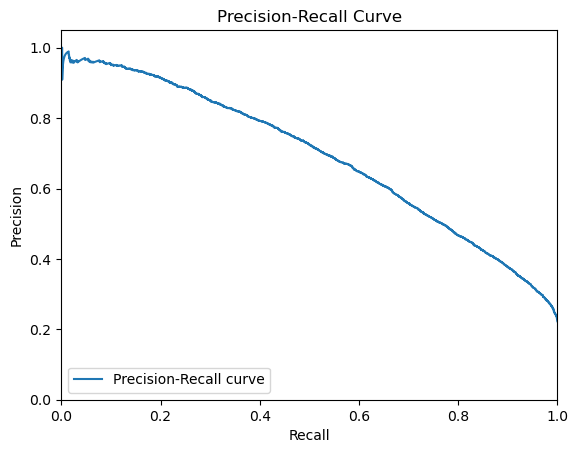

 67%|██████▋   | 8/12 [02:24<01:32, 23.10s/it]


Confusion Matrix:
 [[20988  1110]
 [ 2975  3366]]


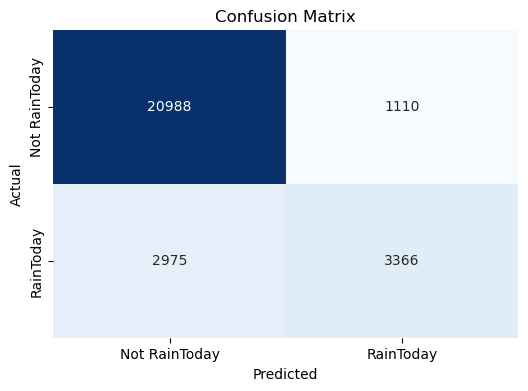


Classification Report:

               precision    recall  f1-score   support

Not RainToday       0.88      0.95      0.91     22098
    RainToday       0.75      0.53      0.62      6341

     accuracy                           0.86     28439
    macro avg       0.81      0.74      0.77     28439
 weighted avg       0.85      0.86      0.85     28439

ROC-AUC: 0.8778344245071157


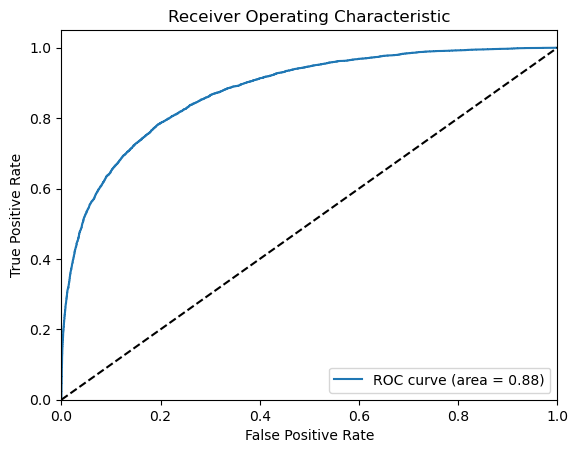

PR AUC: 0.7234971177359354


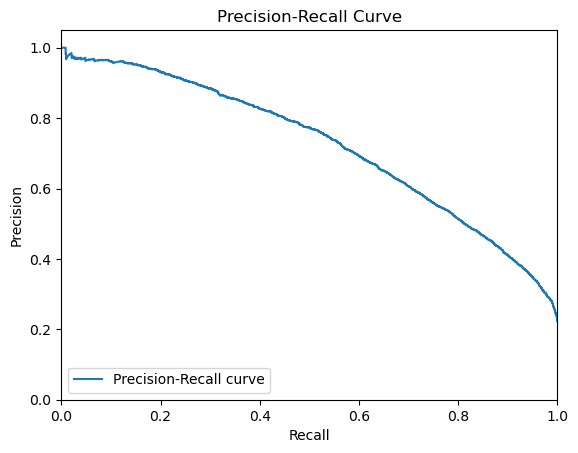

 75%|███████▌  | 9/12 [02:27<00:49, 16.58s/it]e:\programdata\anconda3\envs\Ahmed\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:36:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Confusion Matrix:
 [[20930  1168]
 [ 2855  3486]]


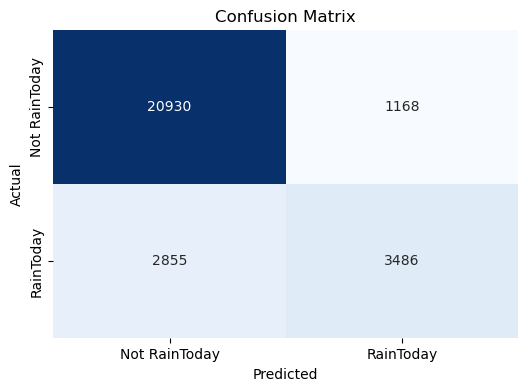


Classification Report:

               precision    recall  f1-score   support

Not RainToday       0.88      0.95      0.91     22098
    RainToday       0.75      0.55      0.63      6341

     accuracy                           0.86     28439
    macro avg       0.81      0.75      0.77     28439
 weighted avg       0.85      0.86      0.85     28439

ROC-AUC: 0.8845064070589543


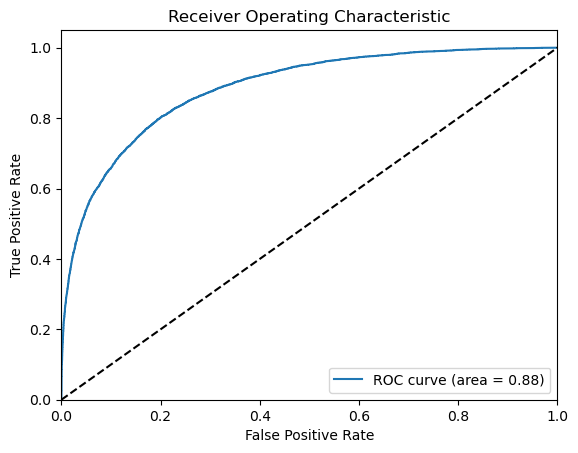

PR AUC: 0.7347546268208978


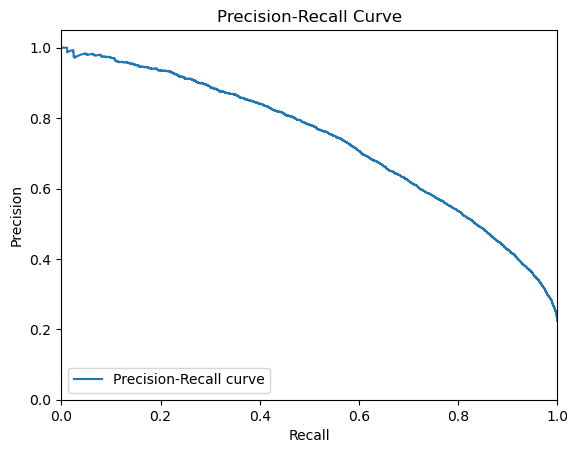

 83%|████████▎ | 10/12 [02:28<00:23, 11.92s/it]


Confusion Matrix:
 [[21037  1061]
 [ 2828  3513]]


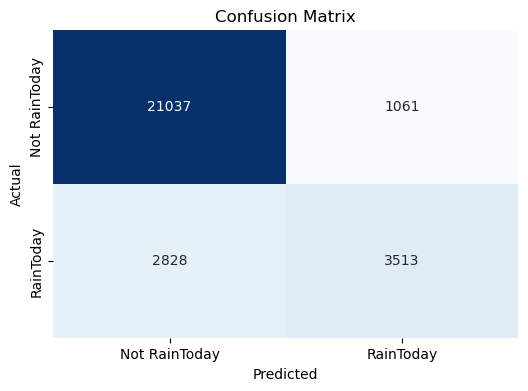


Classification Report:

               precision    recall  f1-score   support

Not RainToday       0.88      0.95      0.92     22098
    RainToday       0.77      0.55      0.64      6341

     accuracy                           0.86     28439
    macro avg       0.82      0.75      0.78     28439
 weighted avg       0.86      0.86      0.85     28439

ROC-AUC: 0.8894897710816618


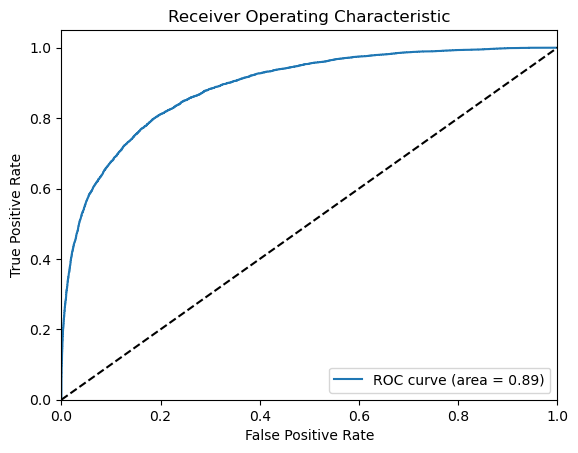

PR AUC: 0.7467344953294424


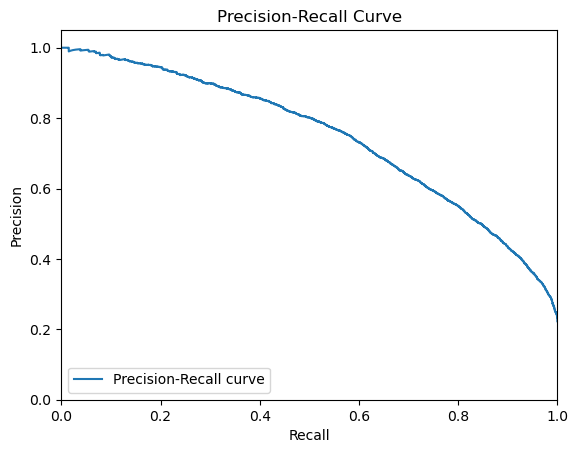

 92%|█████████▏| 11/12 [02:47<00:13, 13.91s/it]

[LightGBM] [Info] Number of positive: 25536, number of negative: 88218
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003527 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2288
[LightGBM] [Info] Number of data points in the train set: 113754, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.224484 -> initscore=-1.239722
[LightGBM] [Info] Start training from score -1.239722

Confusion Matrix:
 [[20956  1142]
 [ 2960  3381]]


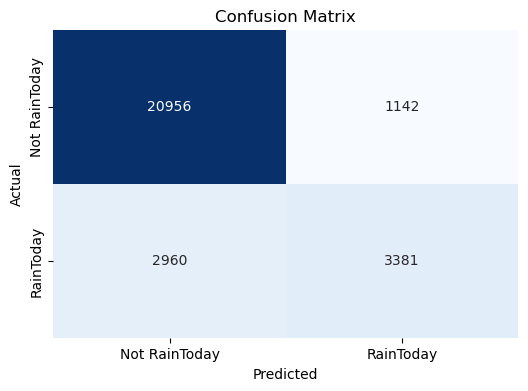


Classification Report:

               precision    recall  f1-score   support

Not RainToday       0.88      0.95      0.91     22098
    RainToday       0.75      0.53      0.62      6341

     accuracy                           0.86     28439
    macro avg       0.81      0.74      0.77     28439
 weighted avg       0.85      0.86      0.85     28439

ROC-AUC: 0.8775106349461159


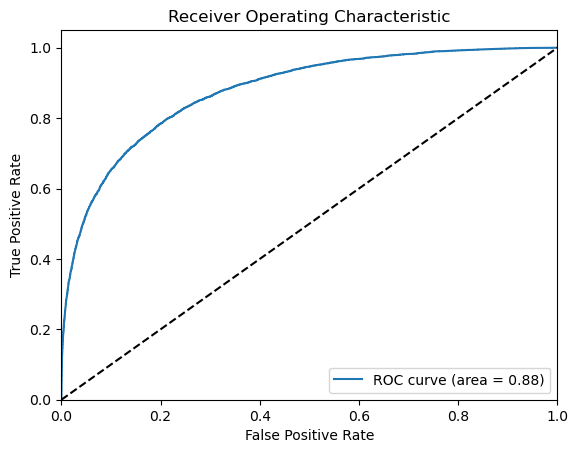

PR AUC: 0.7238096522837776


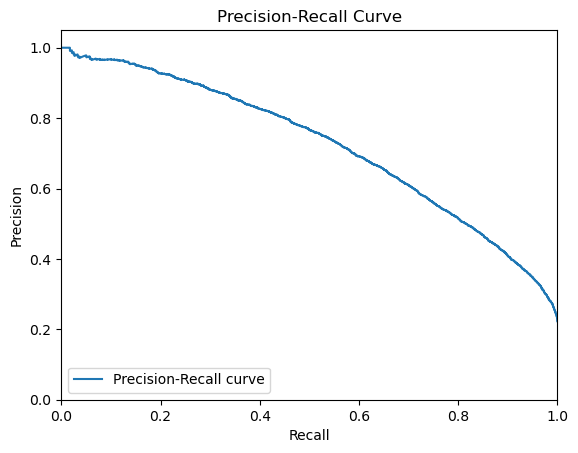

100%|██████████| 12/12 [02:48<00:00, 14.03s/it]


In [42]:
results = {}

for name, model in tqdm(models.items()):
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    test_pred  = model.predict(x_test)

    results[name] = {
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train, train_pred),
        "Test Precision": precision_score(y_test, test_pred),
        "Train Recall": recall_score(y_train, train_pred),
        "Test Recall": recall_score(y_test, test_pred),
        "Train F1 Score": f1_score(y_train, train_pred),
        "Test F1 Score": f1_score(y_test, test_pred),
        "Train Balanced Accuracy": balanced_accuracy_score(y_train, train_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred)

    }

    cm = confusion_matrix(y_test, test_pred)
    print("\nConfusion Matrix:\n", cm)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap='Blues',cbar=False,
                xticklabels=['Not RainToday','RainToday']
                ,yticklabels=['Not RainToday','RainToday'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    plt.show()

    # Full classification report
    print("\nClassification Report:\n")
    print(classification_report(y_test, test_pred,target_names=['Not RainToday','RainToday'],zero_division=0))

    y_pred_prob = model.predict_proba(x_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    print("ROC-AUC:", roc_auc)

    # ROC curve
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(fpr, tpr, label='ROC curve (area = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--') 
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    pr_auc = average_precision_score(y_test, y_pred_prob)
    print("PR AUC:", pr_auc)

    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)
    plt.figure()
    plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()
    

In [44]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1 Score", ascending=False)

In [45]:
results_df


,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Balanced Accuracy,Test Balanced Accuracy
CatBoost,0.887485,0.863251,0.844523,0.768037,0.611333,0.554014,0.709252,0.643701,0.789377,0.753000
XGBoost,0.888268,0.858539,0.838918,0.749033,0.621632,0.549756,0.714112,0.634106,0.793541,0.748450
LightGBM,0.863688,0.855761,0.779294,0.747513,0.547971,0.533197,0.643475,0.622423,0.751524,0.740759
Hist Gradient Boosting,0.863512,0.856359,0.778675,0.752011,0.547658,0.530831,0.643048,0.622354,0.751300,0.740300
Random Forest,0.999974,0.853968,1.000000,0.762728,0.999883,0.500867,0.999941,0.604664,0.999941,0.728079
Extra Trees,1.000000,0.852984,1.000000,0.767724,1.000000,0.488409,1.000000,0.597012,1.000000,0.723003
Gradient Boosting,0.849843,0.846443,0.753584,0.735899,0.491972,0.485570,0.595304,0.585083,0.722703,0.717783
KNN,0.877341,0.831429,0.799411,0.663082,0.605537,0.495979,0.689097,0.567485,0.780778,0.711832
AdaBoost,0.836173,0.833398,0.696963,0.684126,0.478070,0.469642,0.567128,0.556948,0.708951,0.703710
Logistic Regression,0.840199,0.835050,0.719826,0.695035,0.471765,0.463649,0.569975,0.556239,0.709306,0.702636


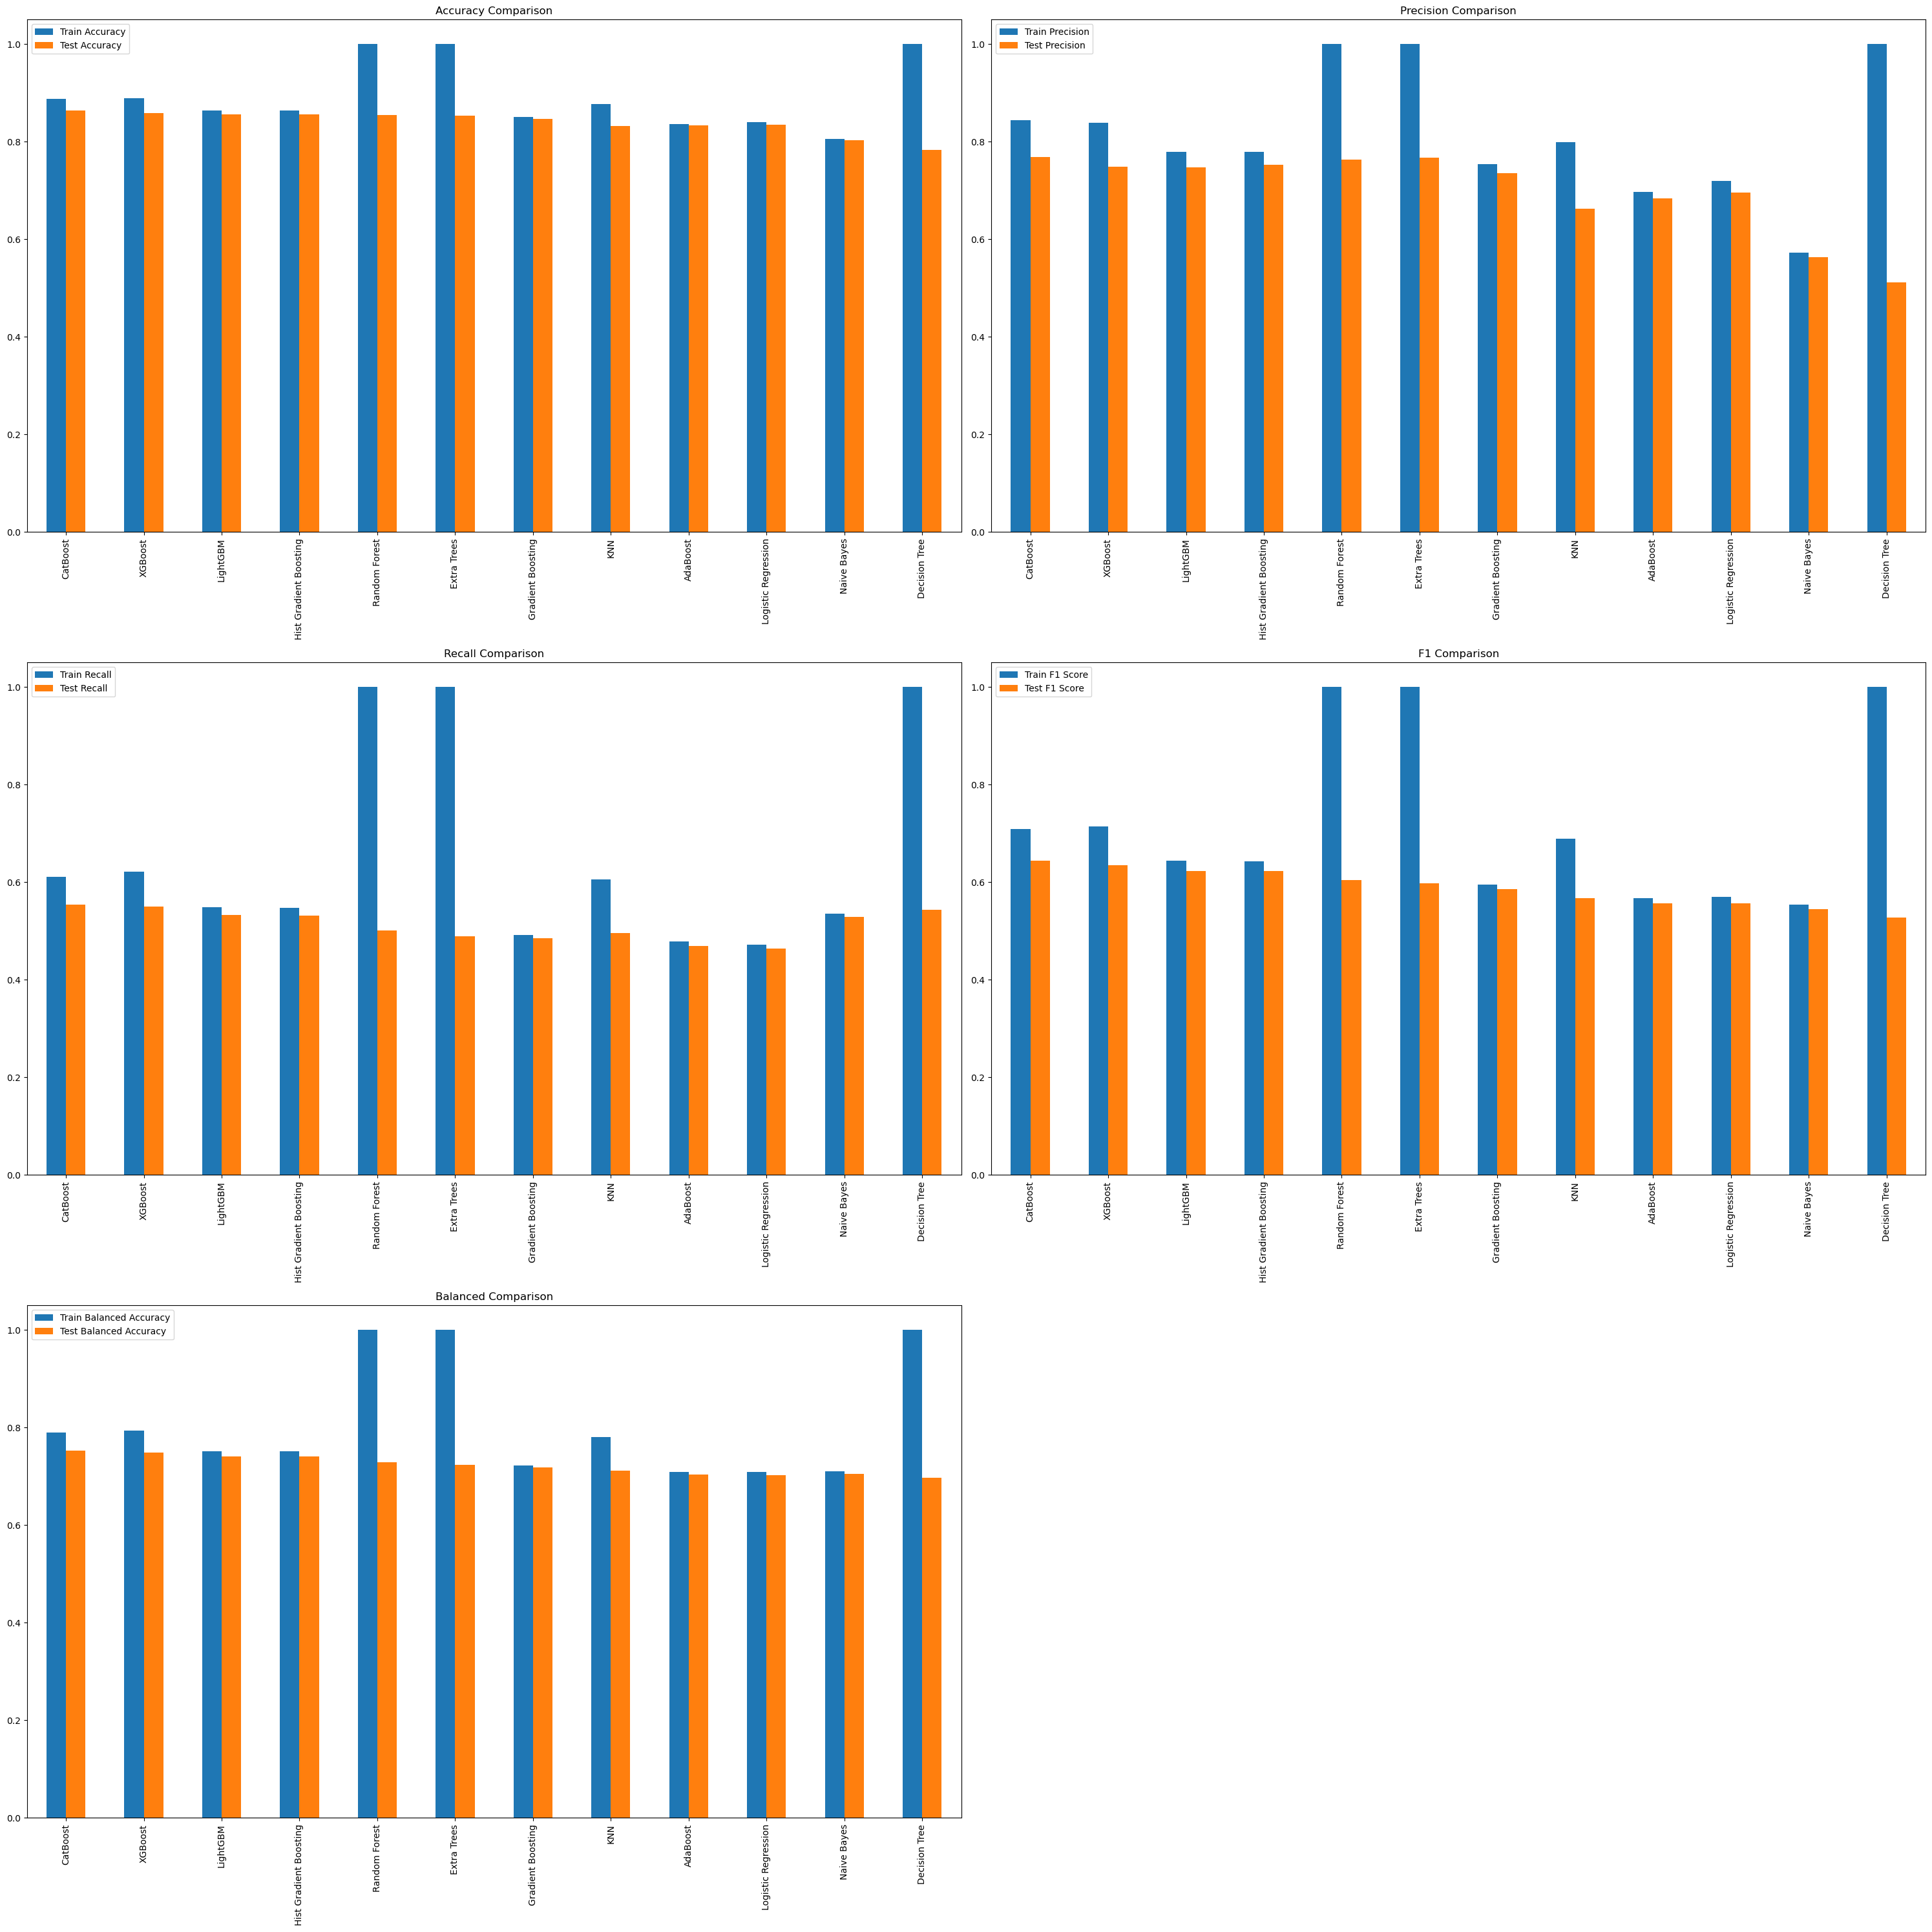

In [46]:
cols = [
    ['Train Accuracy', 'Test Accuracy'],
    ['Train Precision', 'Test Precision'],
    ['Train Recall', 'Test Recall'],
    ['Train F1 Score', 'Test F1 Score'],
    ["Train Balanced Accuracy", "Test Balanced Accuracy"]
]

plt.figure(figsize=(30,30))

for i, col in enumerate(cols):
    ax = plt.subplot(3, 2, i+1)   
    results_df[col].plot.bar(ax=ax)   
    ax.set_title(col[0].split(" ")[1] + ' Comparison')

plt.tight_layout()
plt.show()